# Phân tích kết quả đánh giá RAG với Ragas

Notebook này phân tích kết quả đánh giá hệ thống **Coffee RAG** sử dụng thư viện [Ragas](https://docs.ragas.io/).

## Các metric được sử dụng

| Metric | Ý nghĩa | Đo lường gì? |
|--------|----------|---------------|
| **Context Precision** | Độ chính xác ngữ cảnh | Các đoạn context được truy xuất có *thực sự liên quan* đến câu hỏi không? Giá trị cao = ít context thừa/nhiễu |
| **Context Recall** | Độ phủ ngữ cảnh | Retriever có tìm được *đủ thông tin cần thiết* để trả lời không? Giá trị cao = không bỏ sót thông tin quan trọng |
| **Faithfulness** | Độ trung thực | Câu trả lời LLM có *bám sát* context được cung cấp không? Giá trị thấp = LLM bịa thêm (hallucination) |
| **Answer Relevancy** | Độ phù hợp câu trả lời | Câu trả lời có *đúng trọng tâm* câu hỏi không? Giá trị thấp = trả lời lạc đề hoặc thiếu ý |

Tất cả metric có thang điểm **0 → 1**, càng cao càng tốt.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

PALETTE = {
    "context_precision": "#4C72B0",
    "context_recall": "#DD8452",
    "faithfulness": "#55A868",
    "answer_relevancy": "#C44E52",
}

METRIC_LABELS = {
    "context_precision": "Context Precision\n(Độ chính xác ngữ cảnh)",
    "context_recall": "Context Recall\n(Độ phủ ngữ cảnh)",
    "faithfulness": "Faithfulness\n(Độ trung thực)",
    "answer_relevancy": "Answer Relevancy\n(Độ phù hợp câu trả lời)",
}

## 1. Đọc dữ liệu

Đọc 2 file kết quả:
- `ragas_results_500.csv` — 500 cases, chỉ đánh giá **retrieval** (context_precision + context_recall)
- `ragas_results.csv` — 50 cases, đánh giá **full pipeline** (cả 4 metrics)

Bạn có thể thay đổi đường dẫn file tùy theo kết quả mới nhất.

In [2]:
# --- Đọc file retrieval 500 cases ---
df_ret = pd.read_csv("results/ragas_results_500.csv")
for col in ["context_precision", "context_recall"]:
    df_ret[col] = pd.to_numeric(df_ret[col], errors="coerce")

# --- Đọc file full 50 cases ---
df_full = pd.read_csv("results/ragas_results.csv")
for col in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]:
    if col in df_full.columns:
        df_full[col] = pd.to_numeric(df_full[col], errors="coerce")

print(f"Retrieval dataset: {len(df_ret)} cases")
print(f"Full dataset:      {len(df_full)} cases")
print(f"\nCác intent trong dữ liệu: {sorted(df_ret['intent'].unique())}")
print(f"Các mức difficulty:        {sorted(df_ret['difficulty'].unique())}")
print(f"Ngôn ngữ:                  {sorted(df_ret['language'].unique())}")

Retrieval dataset: 500 cases
Full dataset:      50 cases

Các intent trong dữ liệu: ['comparison', 'edge_case', 'exploration', 'knowledge_qa', 'news_search', 'product_search', 'similar_search']
Các mức difficulty:        ['easy', 'hard', 'medium']
Ngôn ngữ:                  ['en', 'vi']


## 2. Thống kê tổng quan (500 cases — Retrieval)

Bảng thống kê cơ bản cho 2 metric retrieval trên toàn bộ 500 cases.

In [3]:
ret_metrics = ["context_precision", "context_recall"]
stats = df_ret[ret_metrics].describe().T
stats["median"] = df_ret[ret_metrics].median()
stats = stats[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
stats.style.format("{:.3f}").background_gradient(cmap="RdYlGn", subset=["mean", "median"], vmin=0, vmax=1)

,count,mean,std,min,25%,median,75%,max
context_precision,500.000,0.348,0.357,0.000,0.000,0.186,0.629,1.000
context_recall,500.000,0.504,0.378,0.000,0.000,0.500,0.875,1.000


## 3. Phân phối điểm — Retrieval (500 cases)

Biểu đồ histogram + KDE cho thấy **điểm số phân bố như thế nào**.

- Nếu phân phối lệch trái (tập trung ở điểm thấp) → hệ thống retrieval yếu
- Nếu phân phối lệch phải (tập trung ở điểm cao) → retrieval tốt
- Nếu có 2 đỉnh (bimodal) → có nhóm query tốt và nhóm query kém rõ rệt

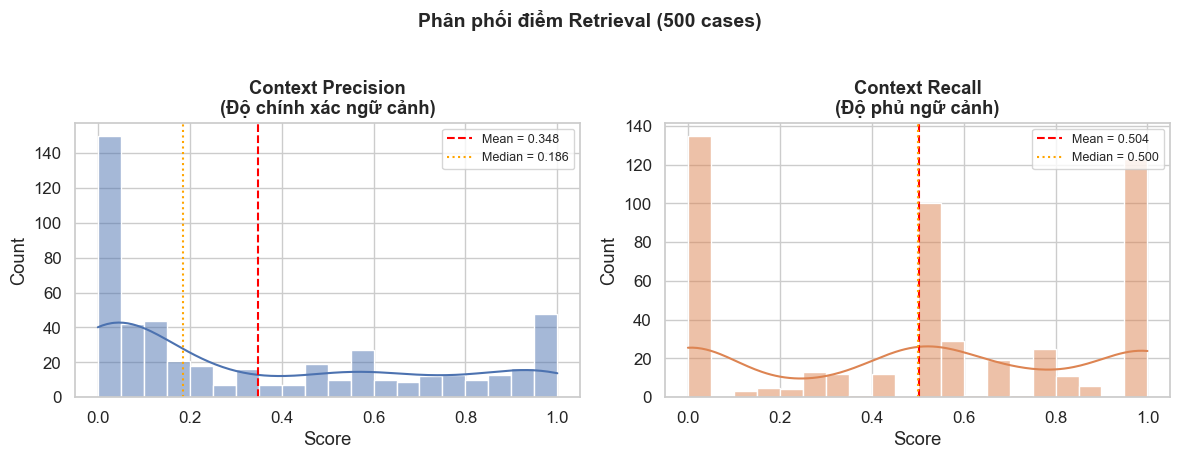

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, col in enumerate(ret_metrics):
    ax = axes[i]
    vals = df_ret[col].dropna()
    sns.histplot(vals, bins=20, kde=True, color=PALETTE[col], ax=ax, edgecolor="white")
    ax.axvline(vals.mean(), color="red", ls="--", lw=1.5, label=f"Mean = {vals.mean():.3f}")
    ax.axvline(vals.median(), color="orange", ls=":", lw=1.5, label=f"Median = {vals.median():.3f}")
    ax.set_title(METRIC_LABELS[col], fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=9)
fig.suptitle("Phân phối điểm Retrieval (500 cases)", fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. Boxplot so sánh các metric (500 cases)

Boxplot cho thấy **trung vị, phân vị, và outlier** của từng metric.

- Hộp (box) = khoảng 25%-75% của dữ liệu
- Đường ngang trong hộp = trung vị (median)
- Các chấm đen = từng case cụ thể
- Điểm nằm ngoài râu = outlier (cases rất tốt hoặc rất kém)

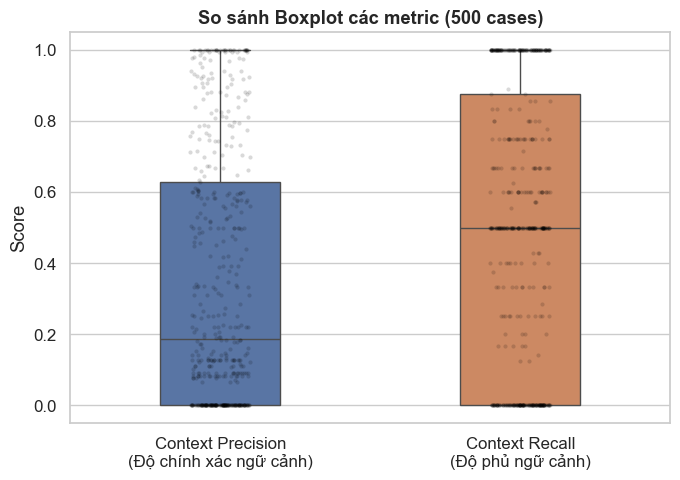

In [5]:
melted = df_ret[ret_metrics].melt(var_name="metric", value_name="score").dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=melted, x="metric", y="score", palette=PALETTE, ax=ax, width=0.4)
sns.stripplot(data=melted, x="metric", y="score", color="black", alpha=0.15, size=3, ax=ax, jitter=True)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("So sánh Boxplot các metric (500 cases)", fontweight="bold")
ax.set_xticks(range(len(ret_metrics)))
ax.set_xticklabels([METRIC_LABELS[m] for m in ret_metrics])
fig.tight_layout()
plt.show()

## 5. Điểm trung bình theo Intent (500 cases)

Biểu đồ này cho biết **loại câu hỏi nào hệ thống xử lý tốt/kém**.

Các intent trong hệ thống:
- `product_search` — Tìm cà phê theo sở thích (vị, xuất xứ, rang...)
- `similar_search` — Tìm cà phê tương tự sản phẩm cho trước
- `comparison` — So sánh 2 loại/phương pháp cà phê
- `knowledge_qa` — Hỏi kiến thức về cà phê
- `news_search` — Tìm tin tức ngành cà phê
- `exploration` — Khám phá/thống kê dữ liệu trong database
- `edge_case` — Cases khó/bất thường

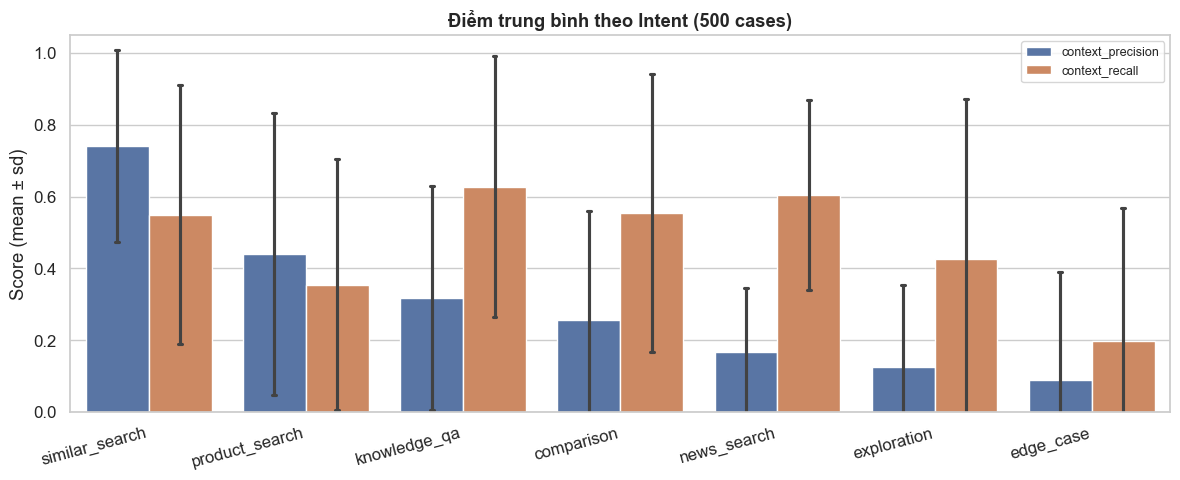

context_precision       context_recall      
                            mean count           mean count
intent                                                     
comparison                 0.256    69          0.554    69
edge_case                  0.090    11          0.197    11
exploration                0.126    61          0.427    61
knowledge_qa               0.317   100          0.627   100
news_search                0.168    69          0.604    69
product_search             0.441   121          0.355   121
similar_search             0.742    69          0.550    69

In [6]:
intent_means = df_ret.groupby("intent")[ret_metrics].mean().sort_values("context_precision", ascending=False)
intent_order = intent_means.index.tolist()

melted = df_ret.melt(id_vars=["intent"], value_vars=ret_metrics, var_name="metric", value_name="score").dropna()
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=melted, x="intent", y="score", hue="metric", palette=PALETTE,
            order=intent_order, ax=ax, errorbar="sd", capsize=0.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Score (mean ± sd)")
ax.set_title("Điểm trung bình theo Intent (500 cases)", fontweight="bold")
ax.legend(title="", fontsize=9)
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
plt.show()

# Bảng số liệu
intent_stats = df_ret.groupby("intent")[ret_metrics].agg(["mean", "count"]).round(3)
intent_stats

## 6. Điểm trung bình theo Difficulty (500 cases)

So sánh hiệu suất giữa các mức độ khó:
- `easy` — Câu hỏi đơn giản, entity rõ ràng
- `medium` — Nhiều điều kiện lọc hoặc yêu cầu phức tạp hơn
- `hard` — Câu hỏi khó, entity hiếm, hoặc yêu cầu kiến thức sâu

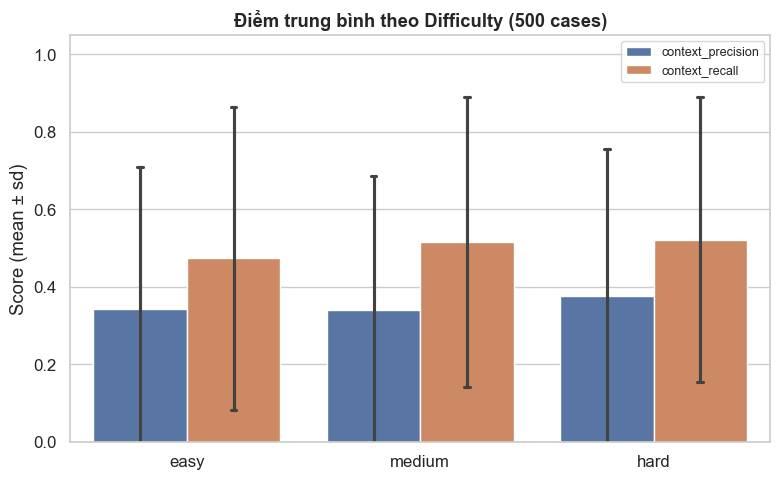

context_precision       context_recall      
                        mean count           mean count
difficulty                                             
easy                   0.343   151          0.473   151
hard                   0.376    94          0.522    94
medium                 0.341   255          0.515   255

In [7]:
diff_order = [d for d in ["easy", "medium", "hard"] if d in df_ret["difficulty"].values]
melted = df_ret.melt(id_vars=["difficulty"], value_vars=ret_metrics, var_name="metric", value_name="score").dropna()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=melted, x="difficulty", y="score", hue="metric", palette=PALETTE,
            order=diff_order, ax=ax, errorbar="sd", capsize=0.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Score (mean ± sd)")
ax.set_title("Điểm trung bình theo Difficulty (500 cases)", fontweight="bold")
ax.legend(title="", fontsize=9)
fig.tight_layout()
plt.show()

df_ret.groupby("difficulty")[ret_metrics].agg(["mean", "count"]).round(3)

## 7. Điểm trung bình theo Ngôn ngữ (500 cases)

So sánh hiệu suất giữa câu hỏi tiếng Việt (`vi`) và tiếng Anh (`en`).

Lưu ý: Knowledge base (beans + news) chủ yếu bằng tiếng Anh, nên query tiếng Việt có thể bị bất lợi khi tìm kiếm ngữ nghĩa (semantic search).

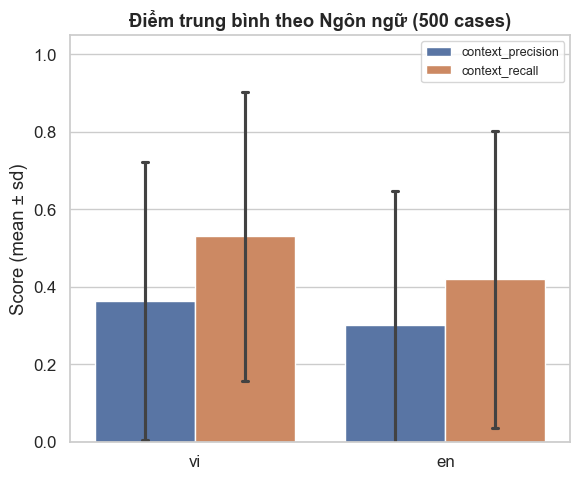

context_precision       context_recall      
                      mean count           mean count
language                                             
en                   0.301   121          0.419   121
vi                   0.363   379          0.531   379

In [8]:
melted = df_ret.melt(id_vars=["language"], value_vars=ret_metrics, var_name="metric", value_name="score").dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=melted, x="language", y="score", hue="metric", palette=PALETTE,
            ax=ax, errorbar="sd", capsize=0.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Score (mean ± sd)")
ax.set_title("Điểm trung bình theo Ngôn ngữ (500 cases)", fontweight="bold")
ax.legend(title="", fontsize=9)
fig.tight_layout()
plt.show()

df_ret.groupby("language")[ret_metrics].agg(["mean", "count"]).round(3)

## 8. Scatter: Context Precision vs Context Recall (500 cases)

Biểu đồ phân tán cho thấy **mối quan hệ giữa precision và recall** cho từng case.

- **Góc trên phải** (precision cao + recall cao) = cases tốt nhất
- **Góc dưới trái** (cả hai thấp) = cases kém nhất, cần cải thiện
- **Trên trái** (precision thấp, recall cao) = tìm đủ thông tin nhưng lẫn nhiều context không liên quan
- **Dưới phải** (precision cao, recall thấp) = context tìm được thì chính xác nhưng thiếu thông tin

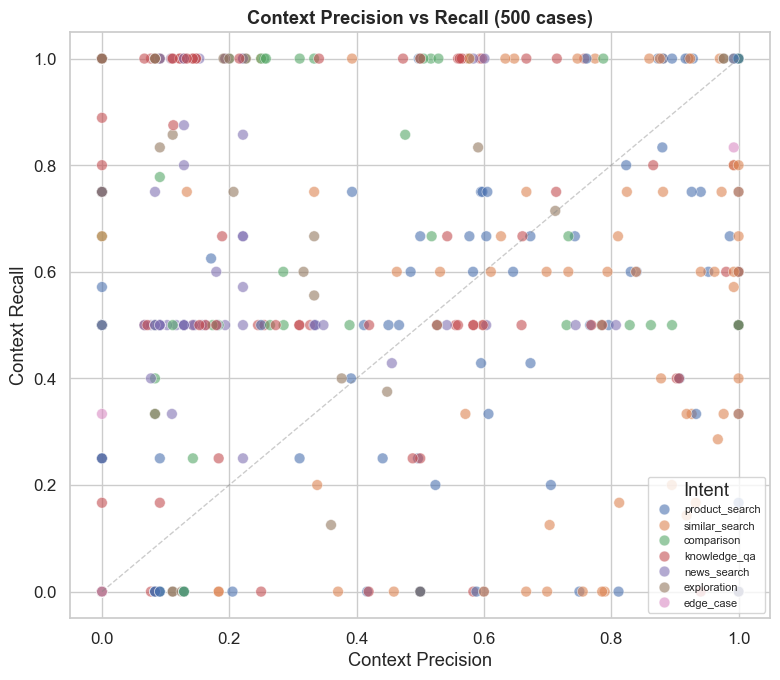

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=df_ret, x="context_precision", y="context_recall", hue="intent",
                s=60, alpha=0.6, ax=ax, edgecolor="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], ls="--", color="gray", alpha=0.4, lw=1)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Context Precision")
ax.set_ylabel("Context Recall")
ax.set_title("Context Precision vs Recall (500 cases)", fontweight="bold")
ax.legend(title="Intent", fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## 9. Heatmap: Intent × Metric (500 cases)

Ma trận nhiệt cho thấy **điểm trung bình của từng metric cho từng intent**.

- Ô màu xanh đậm = điểm cao (tốt)
- Ô màu đỏ = điểm thấp (cần cải thiện)

Dùng bảng này để xác định nhanh **intent nào cần ưu tiên cải thiện**.

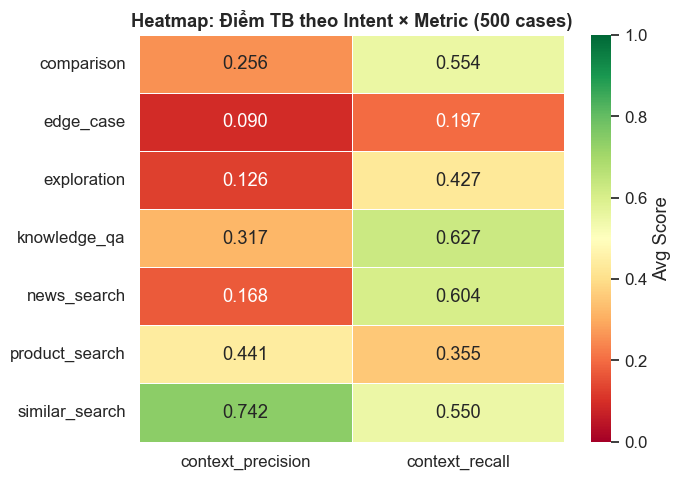

In [10]:
pivot = df_ret.groupby("intent")[ret_metrics].mean()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Avg Score"})
ax.set_title("Heatmap: Điểm TB theo Intent × Metric (500 cases)", fontweight="bold")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 10. Tỷ lệ thất bại (score < 0.3) theo Intent

"Thất bại" = case có điểm < 0.3 (ngưỡng tùy chỉnh).

Biểu đồ này cho thấy **% cases thất bại ở mỗi intent**, giúp xác định nhóm query nào cần cải thiện cấp bách nhất.

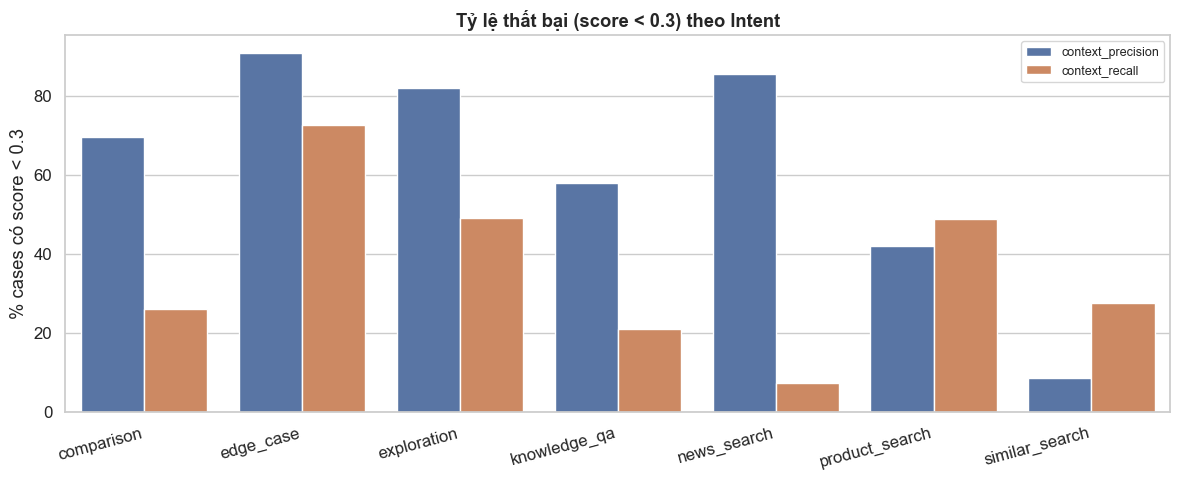

In [11]:
THRESHOLD = 0.3

fail_data = []
for intent in sorted(df_ret["intent"].unique()):
    sub = df_ret[df_ret["intent"] == intent]
    for m in ret_metrics:
        vals = sub[m].dropna()
        if len(vals) == 0:
            continue
        fail_pct = (vals < THRESHOLD).sum() / len(vals) * 100
        fail_data.append({"intent": intent, "metric": m, "fail_pct": fail_pct})

fdf = pd.DataFrame(fail_data)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=fdf, x="intent", y="fail_pct", hue="metric", palette=PALETTE, ax=ax)
ax.set_ylabel(f"% cases có score < {THRESHOLD}")
ax.set_xlabel("")
ax.set_title(f"Tỷ lệ thất bại (score < {THRESHOLD}) theo Intent", fontweight="bold")
ax.legend(title="", fontsize=9)
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
plt.show()

## 11. Phân tích thời gian xử lý

- **Trái**: Phân phối thời gian xử lý mỗi case
- **Phải**: Thời gian xử lý trung bình theo intent

Thời gian bao gồm: retrieval (FAISS search + structured filter) + Ragas evaluator API calls.

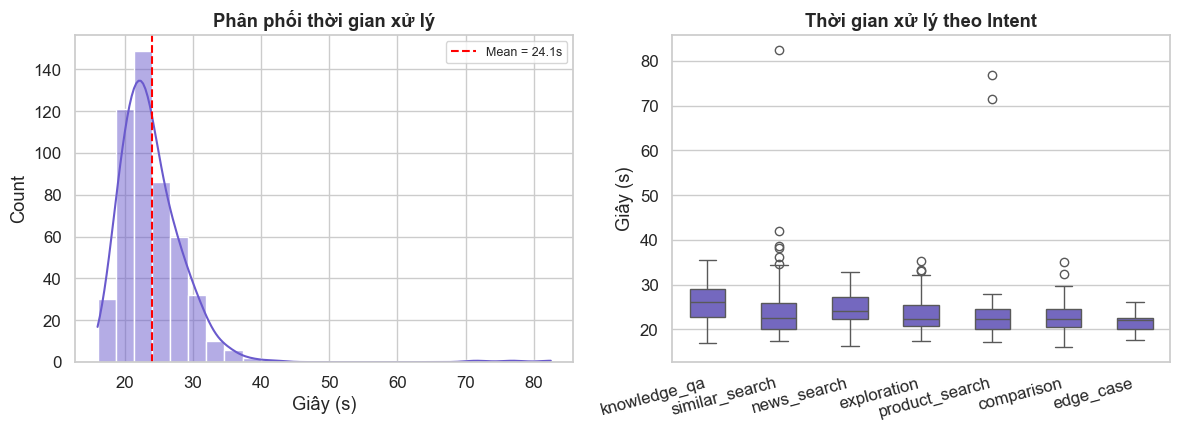

In [12]:
if "elapsed_s" in df_ret.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    vals = df_ret["elapsed_s"].dropna()

    sns.histplot(vals, bins=25, kde=True, color="#6A5ACD", ax=axes[0], edgecolor="white")
    axes[0].axvline(vals.mean(), color="red", ls="--", lw=1.5, label=f"Mean = {vals.mean():.1f}s")
    axes[0].set_title("Phân phối thời gian xử lý", fontweight="bold")
    axes[0].set_xlabel("Giây (s)")
    axes[0].legend(fontsize=9)

    intent_order = df_ret.groupby("intent")["elapsed_s"].mean().sort_values(ascending=False).index
    sns.boxplot(data=df_ret, x="intent", y="elapsed_s", color="#6A5ACD", ax=axes[1], width=0.5, order=intent_order)
    axes[1].set_title("Thời gian xử lý theo Intent", fontweight="bold")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Giây (s)")
    plt.sca(axes[1])
    plt.xticks(rotation=15, ha="right")

    fig.tight_layout()
    plt.show()
else:
    print("Cột elapsed_s không có trong dữ liệu.")

---

# Phần 2: Phân tích Full Pipeline (50 cases)

Phần này phân tích kết quả **full mode** — bao gồm cả LLM generation.

Ngoài context_precision và context_recall, ta có thêm:
- **Faithfulness**: LLM có bịa thêm thông tin không?
- **Answer Relevancy**: Câu trả lời có đúng trọng tâm không?

In [13]:
full_metrics = [c for c in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]
                if c in df_full.columns and df_full[c].notna().sum() > 0]

print(f"Full dataset: {len(df_full)} cases")
print(f"Metrics có dữ liệu: {full_metrics}")

stats_full = df_full[full_metrics].describe().T
stats_full["median"] = df_full[full_metrics].median()
stats_full = stats_full[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
stats_full.style.format("{:.3f}").background_gradient(cmap="RdYlGn", subset=["mean", "median"], vmin=0, vmax=1)

Full dataset: 50 cases
Metrics có dữ liệu: ['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']


,count,mean,std,min,25%,median,75%,max
context_precision,50.000,0.611,0.346,0.000,0.387,0.654,0.919,1.000
context_recall,50.000,0.743,0.292,0.000,0.667,0.800,1.000,1.000
faithfulness,49.000,0.709,0.190,0.200,0.600,0.714,0.833,1.000
answer_relevancy,50.000,0.550,0.248,0.000,0.423,0.606,0.716,0.910


## 12. Phân phối điểm — Full Pipeline (50 cases)

Histogram của cả 4 metrics trong full mode.

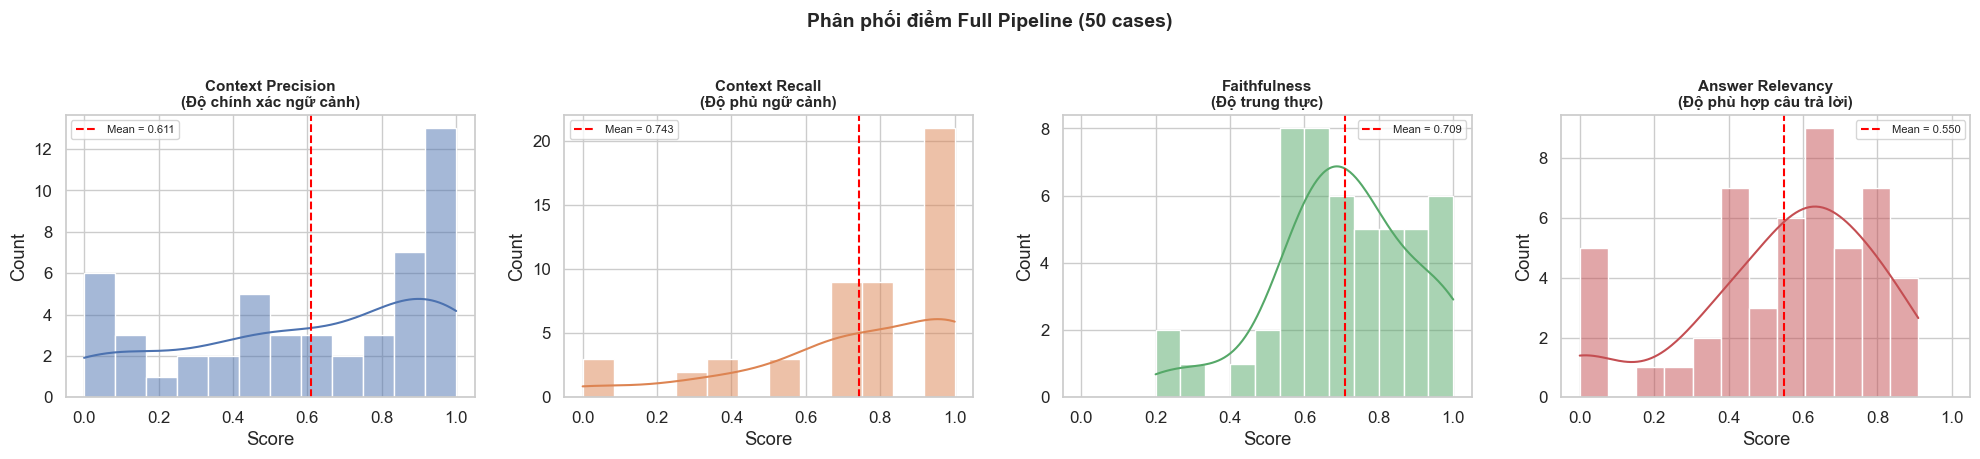

In [14]:
n = len(full_metrics)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
for i, col in enumerate(full_metrics):
    ax = axes[0, i]
    vals = df_full[col].dropna()
    sns.histplot(vals, bins=12, kde=True, color=PALETTE.get(col, "#4C72B0"), ax=ax, edgecolor="white")
    ax.axvline(vals.mean(), color="red", ls="--", lw=1.5, label=f"Mean = {vals.mean():.3f}")
    ax.set_title(METRIC_LABELS.get(col, col), fontweight="bold", fontsize=11)
    ax.set_xlabel("Score")
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=8)
fig.suptitle("Phân phối điểm Full Pipeline (50 cases)", fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 13. Boxplot so sánh 4 metrics (50 cases)

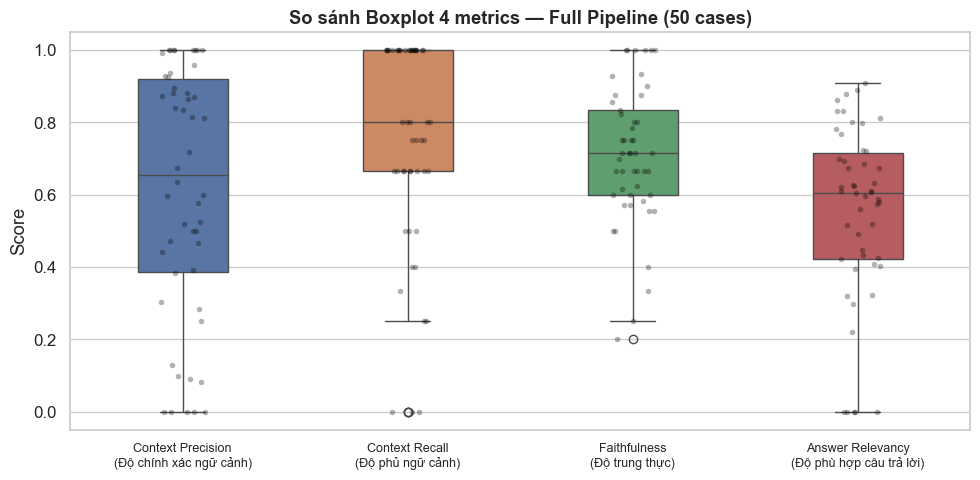

In [15]:
melted = df_full[full_metrics].melt(var_name="metric", value_name="score").dropna()
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=melted, x="metric", y="score", palette=PALETTE, ax=ax, width=0.4)
sns.stripplot(data=melted, x="metric", y="score", color="black", alpha=0.3, size=4, ax=ax, jitter=True)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("So sánh Boxplot 4 metrics — Full Pipeline (50 cases)", fontweight="bold")
ax.set_xticks(range(len(full_metrics)))
ax.set_xticklabels([METRIC_LABELS.get(m, m) for m in full_metrics], fontsize=9)
fig.tight_layout()
plt.show()

## 14. Scatter: Faithfulness vs Context Recall

Mối quan hệ giữa **độ phủ ngữ cảnh** và **độ trung thực**:

- **Recall cao + Faithfulness cao** (góc trên phải) = lý tưởng
- **Recall cao + Faithfulness thấp** = retriever tốt nhưng LLM bịa thêm (hallucinate)
- **Recall thấp + Faithfulness cao** = LLM cẩn thận nhưng thiếu thông tin
- **Recall thấp + Faithfulness thấp** = cả retriever lẫn LLM đều có vấn đề

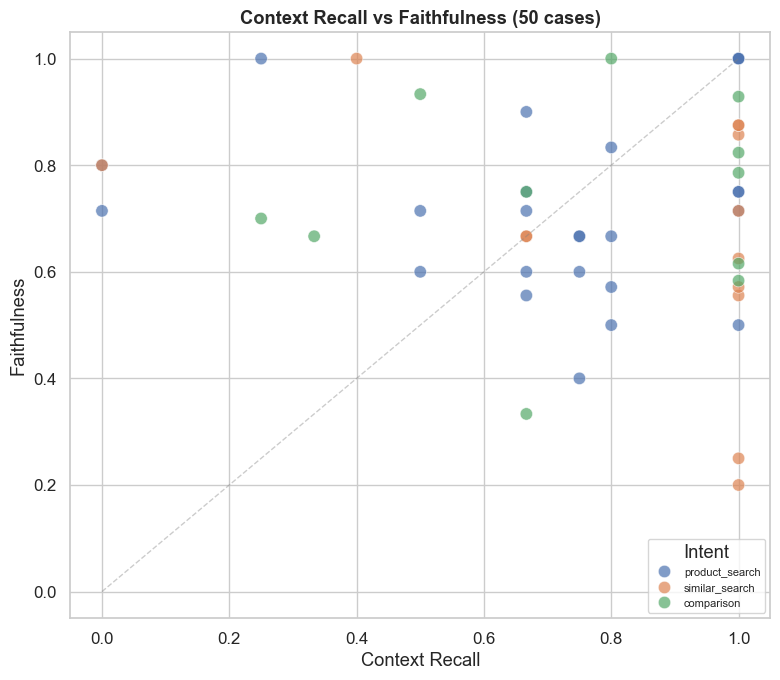

In [16]:
if "faithfulness" in df_full.columns and "context_recall" in df_full.columns:
    sub = df_full[["context_recall", "faithfulness", "intent"]].dropna()
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.scatterplot(data=sub, x="context_recall", y="faithfulness", hue="intent",
                    s=80, alpha=0.7, ax=ax, edgecolor="white", linewidth=0.5)
    ax.plot([0, 1], [0, 1], ls="--", color="gray", alpha=0.4, lw=1)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Context Recall")
    ax.set_ylabel("Faithfulness")
    ax.set_title("Context Recall vs Faithfulness (50 cases)", fontweight="bold")
    ax.legend(title="Intent", fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()
else:
    print("Cần chạy --mode full để có dữ liệu faithfulness.")

## 15. Heatmap: Intent × Metric — Full Pipeline (50 cases)

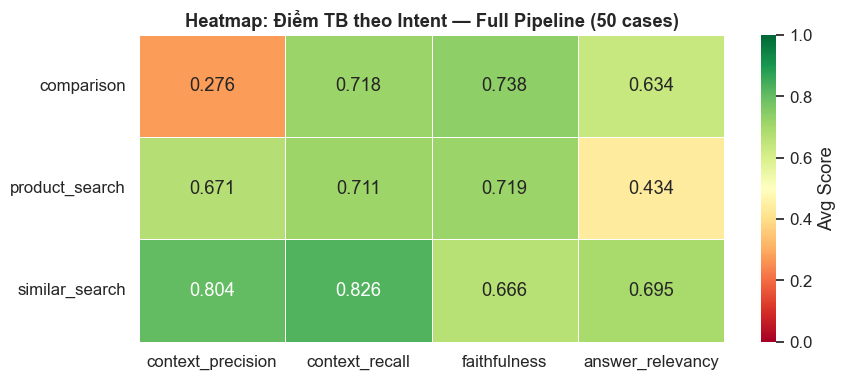

In [17]:
if df_full["intent"].nunique() > 1:
    pivot = df_full.groupby("intent")[full_metrics].mean()
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax, cbar_kws={"label": "Avg Score"})
    ax.set_title("Heatmap: Điểm TB theo Intent — Full Pipeline (50 cases)", fontweight="bold")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

## 16. Top cases kém nhất (cần cải thiện)

Liệt kê **5 cases có điểm thấp nhất** cho mỗi metric.

Đây là nơi bắt đầu debug: xem câu hỏi gì, intent gì, và context nào đã được truy xuất.

In [18]:
display_cols = ["id", "intent", "difficulty", "language", "question"]

for m in ret_metrics:
    bottom = df_ret.nsmallest(5, m)[display_cols + [m]].copy()
    bottom["question"] = bottom["question"].str[:80]
    print(f"\n{'─' * 80}")
    print(f"Bottom 5 — {m}")
    print(f"{'─' * 80}")
    display(bottom)


────────────────────────────────────────────────────────────────────────────────
Bottom 5 — context_precision
────────────────────────────────────────────────────────────────────────────────


,id,intent,difficulty,language,question,context_precision
9,PS_010,product_search,easy,en,Suggest a coffee with floral and jasmine notes...,0.0
25,SS_001,similar_search,medium,vi,Gợi ý cà phê tương tự 'MIDNIGHT CHOCOLATE' của...,0.0
48,CP_011,comparison,hard,vi,So sánh hai roaster Every Half và The Workshop...,0.0
58,KQ_008,knowledge_qa,hard,vi,Maillard reaction trong rang cà phê là gì và ả...,0.0
59,KQ_009,knowledge_qa,medium,vi,Cupping là gì?,0.0



────────────────────────────────────────────────────────────────────────────────
Bottom 5 — context_recall
────────────────────────────────────────────────────────────────────────────────


,id,intent,difficulty,language,question,context_recall
3,PS_004,product_search,medium,vi,Gợi ý cà phê Geisha Panama rang light có vị ho...,0.0
21,PS_022,product_search,easy,en,Suggest a Tanzanian Peaberry medium roast coffee.,0.0
25,SS_001,similar_search,medium,vi,Gợi ý cà phê tương tự 'MIDNIGHT CHOCOLATE' của...,0.0
51,KQ_001,knowledge_qa,easy,vi,Specialty coffee là gì?,0.0
62,KQ_012,knowledge_qa,medium,vi,Terroir trong cà phê nghĩa là gì?,0.0


## 17. Tổng kết & Khuyến nghị

Dựa trên kết quả phân tích, tóm tắt các phát hiện chính và hướng cải thiện.

In [19]:
print("=" * 70)
print("TỔNG KẾT")
print("=" * 70)

for m in ret_metrics:
    avg = df_ret[m].mean()
    status = "✓ Tốt" if avg >= 0.7 else "△ Trung bình" if avg >= 0.5 else "✗ Cần cải thiện"
    print(f"  {m:<24s}  avg={avg:.3f}  → {status}")

if full_metrics:
    print()
    for m in full_metrics:
        if m in df_full.columns:
            avg = df_full[m].mean()
            status = "✓ Tốt" if avg >= 0.7 else "△ Trung bình" if avg >= 0.5 else "✗ Cần cải thiện"
            print(f"  {m:<24s}  avg={avg:.3f}  → {status}  (full, {len(df_full)} cases)")

# Intent yếu nhất
worst_intent = df_ret.groupby("intent")["context_precision"].mean().idxmin()
worst_score = df_ret.groupby("intent")["context_precision"].mean().min()
print(f"\n  Intent yếu nhất (precision): {worst_intent} ({worst_score:.3f})")

worst_recall_intent = df_ret.groupby("intent")["context_recall"].mean().idxmin()
worst_recall = df_ret.groupby("intent")["context_recall"].mean().min()
print(f"  Intent yếu nhất (recall):    {worst_recall_intent} ({worst_recall:.3f})")

print(f"\n{'=' * 70}")
print("KHUYẾN NGHỊ CẢI THIỆN:")
print("─" * 70)

ret_prec = df_ret["context_precision"].mean()
ret_rec = df_ret["context_recall"].mean()

suggestions = []
if ret_prec < 0.5:
    suggestions.append("1. Context Precision thấp → Giảm top_k hoặc cải thiện reranking để loại bỏ context không liên quan")
if ret_rec < 0.6:
    suggestions.append("2. Context Recall thấp → Cải thiện embedding model hoặc thêm hybrid search (BM25 + semantic)")
if "faithfulness" in full_metrics and df_full["faithfulness"].mean() < 0.7:
    suggestions.append("3. Faithfulness thấp → Cải thiện prompt để LLM bám sát context, tránh hallucination")
if "answer_relevancy" in full_metrics and df_full["answer_relevancy"].mean() < 0.6:
    suggestions.append("4. Answer Relevancy thấp → Cải thiện prompt template hoặc thử model LLM khác")

if not suggestions:
    suggestions.append("Hệ thống hoạt động tốt! Tiếp tục theo dõi với nhiều test cases hơn.")

for s in suggestions:
    print(f"  {s}")
print(f"{'=' * 70}")

TỔNG KẾT
  context_precision         avg=0.348  → ✗ Cần cải thiện
  context_recall            avg=0.504  → △ Trung bình

  context_precision         avg=0.611  → △ Trung bình  (full, 50 cases)
  context_recall            avg=0.743  → ✓ Tốt  (full, 50 cases)
  faithfulness              avg=0.709  → ✓ Tốt  (full, 50 cases)
  answer_relevancy          avg=0.550  → △ Trung bình  (full, 50 cases)

  Intent yếu nhất (precision): edge_case (0.090)
  Intent yếu nhất (recall):    edge_case (0.197)

KHUYẾN NGHỊ CẢI THIỆN:
──────────────────────────────────────────────────────────────────────
  1. Context Precision thấp → Giảm top_k hoặc cải thiện reranking để loại bỏ context không liên quan
  2. Context Recall thấp → Cải thiện embedding model hoặc thêm hybrid search (BM25 + semantic)
  4. Answer Relevancy thấp → Cải thiện prompt template hoặc thử model LLM khác
